# Demand Forecasting Models

This notebook trains and evaluates forecasting models to predict daily trip count. It starts with naive baselines, then build progressively more powerful models.

| Model | Type | Key Idea |
|-------|------|----------|
| Same-Day-Last-Week | Naive baseline | Use last week's same-day count as the forecast |
| 7-Day Moving Average | Naive baseline | Average of the past 7 days |
| Linear Regression | Parametric | Weighted sum of engineered features |
| Random Forest | Ensemble | Averaging many decision trees to reduce variance |

Evaluation protocol: Temporal split; train on the first ~277 days, test on the last 60 days (~Nov–Dec 2023). Metrics: RMSE, MAE, MAPE.

Starting with baselines ensures our engineered models are actually learning something. If they can't beat a simple rule-of-thumb, the extra complexity is not justified.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")


def mape(y_true, y_pred):
    """Mean Absolute Percentage Error."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100


def evaluate(y_true, y_pred, model_name):
    """Print and return evaluation metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    print(f"\n{model_name}")
    print(f"  RMSE: {rmse:,.1f}")
    print(f"  MAE:  {mae:,.1f}")
    print(f"  MAPE: {mape_val:.2f}%")
    return {"model": model_name, "RMSE": rmse, "MAE": mae, "MAPE": mape_val}

### Load Data and Train/Test Split

In [2]:
daily = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "daily_features.csv",
    index_col="date",
    parse_dates=True,
)
print(f"{len(daily)} days loaded")

TEST_DAYS = 60
split_date = daily.index[-TEST_DAYS]

train = daily[daily.index < split_date]
test = daily[daily.index >= split_date]

y_train = train["trip_count"]
y_test = test["trip_count"]

print(f"Train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test: {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

337 days loaded
Train: 277 days (2023-01-29 to 2023-11-01)
Test: 60 days (2023-11-02 to 2023-12-31)


### Naive Baselines

Before building any model, we establish two simple baselines:

1. Same-Day-Last-Week: Predict today's trips = same weekday last week. This captures the strong weekly pattern we saw in EDA.
2. 7-Day Moving Average: Predict today's trips = mean of the past 7 days. This smooths out day-to-day noise.

In [3]:
# Baseline 1: Same day last week (lag-7)
baseline_lag7 = test["trip_count_lag7"].values

# Baseline 2: 7-day rolling mean (already computed, shifted by 1 to avoid leakage)
baseline_rmean7 = test["trip_count_rmean7"].values

results = []
results.append(evaluate(y_test, baseline_lag7, "Baseline: Same-Day-Last-Week"))
results.append(evaluate(y_test, baseline_rmean7, "Baseline: 7-Day Moving Avg"))


Baseline: Same-Day-Last-Week
  RMSE: 3,090.8
  MAE:  2,484.7
  MAPE: 33.38%

Baseline: 7-Day Moving Avg
  RMSE: 2,362.6
  MAE:  1,880.1
  MAPE: 25.61%


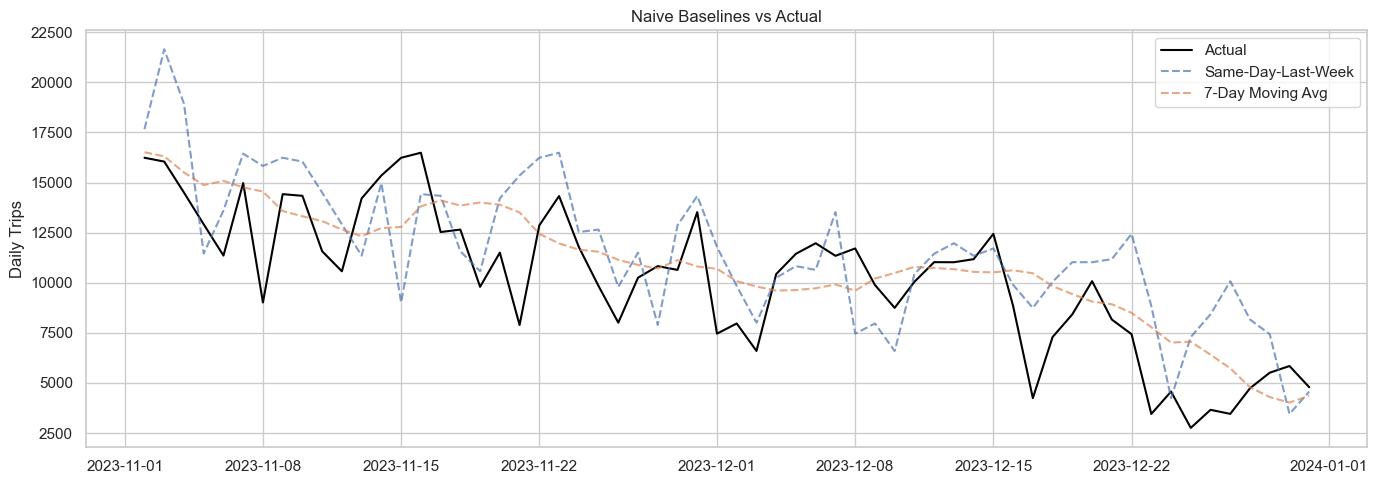

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.index, y_test, label="Actual", color="black", linewidth=1.5)
ax.plot(y_test.index, baseline_lag7, label="Same-Day-Last-Week", linestyle="--", alpha=0.7)
ax.plot(y_test.index, baseline_rmean7, label="7-Day Moving Avg", linestyle="--", alpha=0.7)
ax.set_title("Naive Baselines vs Actual")
ax.set_ylabel("Daily Trips")
ax.legend()
plt.tight_layout()
plt.show()

### Model 1: Linear Regression

A linear model learns a weighted sum of the features. Each coefficient tells us: "holding everything else constant, a 1-unit increase in this feature changes the predicted trip count by this much."

This interpretability makes it a strong first model where we can inspect exactly what the model learned and whether it makes intuitive sense.

In [5]:
from sklearn.linear_model import LinearRegression

# Select features (exclude the target)
feature_cols = [c for c in daily.columns if c != "trip_count"]

X_train = train[feature_cols]
X_test = test[feature_cols]

print(f"Features ({len(feature_cols)}): {feature_cols}")

Features (26): ['mean_duration_min', 'median_duration_min', 'pct_annual_member', 'pct_peak_hour', 'pct_weekend', 'day_of_week', 'month', 'day_of_year', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_weekend', 'is_holiday', 'trip_count_lag1', 'trip_count_lag7', 'trip_count_lag14', 'trip_count_lag28', 'trip_count_rmean7', 'trip_count_rstd7', 'trip_count_rmean14', 'trip_count_rstd14', 'trip_count_rmean28', 'trip_count_rstd28']


In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
results.append(evaluate(y_test, lr_pred, "Linear Regression"))

print(f"\nR-squared (train): {lr.score(X_train, y_train):.4f}")
print(f"R-squared (test): {lr.score(X_test, y_test):.4f}")


Linear Regression
  RMSE: 2,763.5
  MAE:  2,169.7
  MAPE: 26.66%

R-squared (train): 0.9302
R-squared (test): 0.4009


#### Coefficient Analysis

Which features matter most to the linear model? Large absolute coefficients indicate strong influence (keeping in mind that features are on different scales).

Top 10 coefficients (by magnitude):

pct_peak_hour          20777.24
pct_annual_member      17486.74
median_duration_min     5882.31
mean_duration_min      -3658.83
day_of_year_sin        -3506.41
is_holiday             -2217.32
day_of_year_cos        -1774.14
month_cos              -1295.27
month_sin                778.19
is_weekend              -585.10
dtype: float64


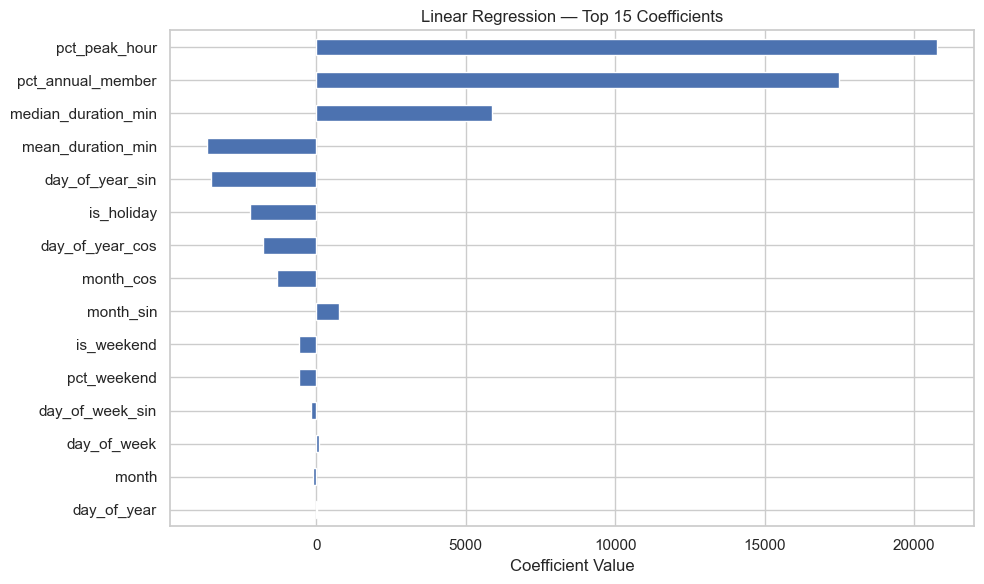

In [7]:
coefficients = pd.Series(lr.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

print("Top 10 coefficients (by magnitude):\n")
print(coefficients.head(10).round(2))

fig, ax = plt.subplots(figsize=(10, 6))
coefficients.head(15).plot(kind="barh", ax=ax)
ax.set_title("Linear Regression — Top 15 Coefficients")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

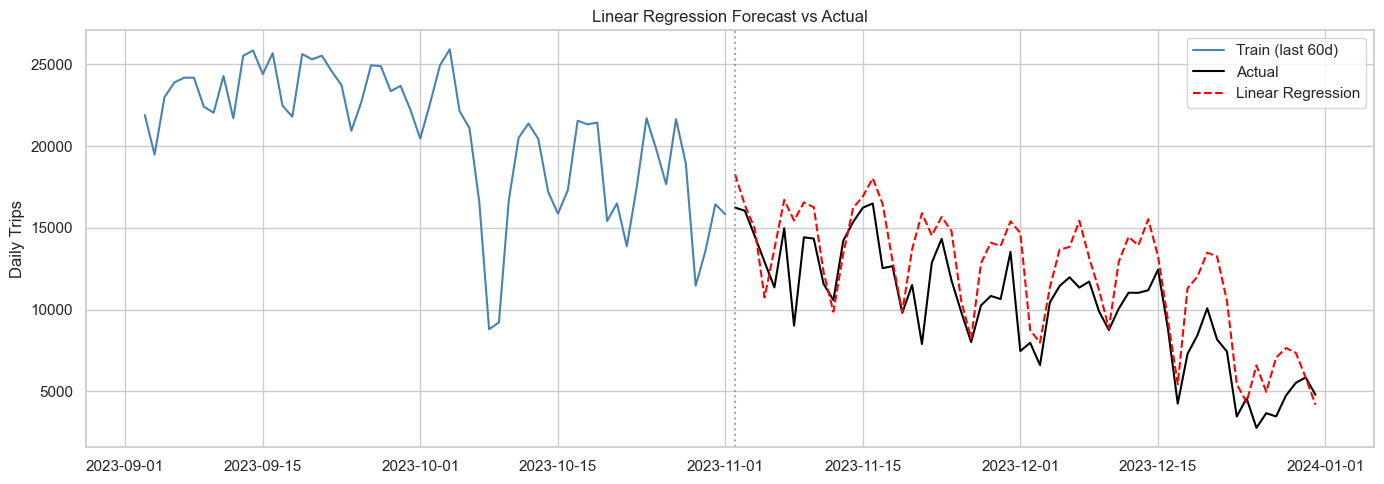

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_train.index[-60:], y_train[-60:], label="Train (last 60d)", color="steelblue")
ax.plot(y_test.index, y_test, label="Actual", color="black", linewidth=1.5)
ax.plot(y_test.index, lr_pred, label="Linear Regression", color="red", linestyle="--")
ax.axvline(split_date, color="grey", linestyle=":", alpha=0.7)
ax.set_title("Linear Regression Forecast vs Actual")
ax.set_ylabel("Daily Trips")
ax.legend()
plt.tight_layout()
plt.show()

### Model 2: Random Forest

A Random Forest is an ensemble of decision trees. Each tree sees a random subset of the data and features, then the forest averages their predictions. This reduces overfitting compared to a single decision tree and can capture non-linear relationships that Linear Regression misses.

#### Baseline Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)
rf_base.fit(X_train, y_train)

rf_base_pred = rf_base.predict(X_test)
results.append(evaluate(y_test, rf_base_pred, "Random Forest (baseline)"))

print(f"\nR-squared (train): {rf_base.score(X_train, y_train):.4f}")
print(f"R-squared (test): {rf_base.score(X_test, y_test):.4f}")


Random Forest (baseline)
  RMSE: 2,916.4
  MAE:  2,322.3
  MAPE: 37.43%

R-squared (train): 0.9848
R-squared (test): 0.3327


#### Hyperparameter Tuning

We tune the Random Forest using GridSearchCV with TimeSeriesSplit.

`TimeSeriesSplit` is critical here: unlike regular k-fold cross-validation, it respects temporal order. Each fold trains on past data and validates on
future data, preventing data leakage from the future into the training set.

Key hyperparameters:
- `n_estimators`: number of trees (more = less variance, more compute)
- `max_depth`: how deep each tree can grow (deeper = more complex, risk of overfitting)
- `min_samples_leaf`: minimum samples in a leaf (higher = more regularization)

In [10]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [6, 10, 15, None],
    "min_samples_leaf": [2, 5, 10],
}

tscv = TimeSeriesSplit(n_splits=3)

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

rf_grid.fit(X_train, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV RMSE: {-rf_grid.best_score_:,.1f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV RMSE: 5,331.7


In [11]:
rf_tuned = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test)

results.append(evaluate(y_test, rf_tuned_pred, "Random Forest (tuned)"))

print(f"\nR-squared (train): {rf_tuned.score(X_train, y_train):.4f}")
print(f"R-squared (test): {rf_tuned.score(X_test, y_test):.4f}")


Random Forest (tuned)
  RMSE: 3,139.2
  MAE:  2,530.7
  MAPE: 40.66%

R-squared (train): 0.9521
R-squared (test): 0.2269


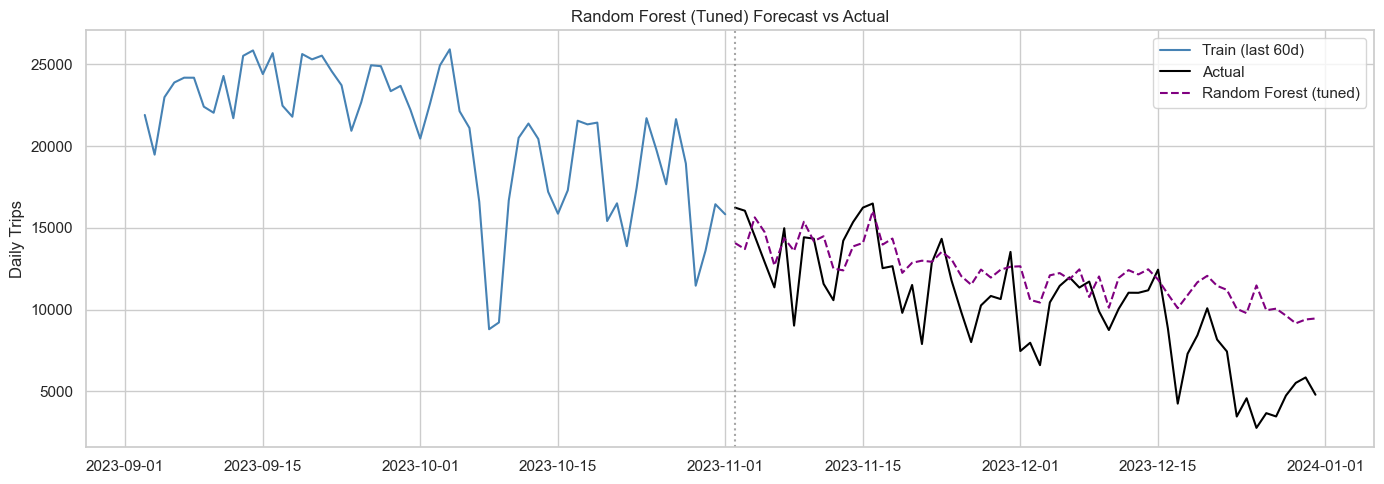

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_train.index[-60:], y_train[-60:], label="Train (last 60d)", color="steelblue")
ax.plot(y_test.index, y_test, label="Actual", color="black", linewidth=1.5)
ax.plot(y_test.index, rf_tuned_pred, label="Random Forest (tuned)", color="purple", linestyle="--")
ax.axvline(split_date, color="grey", linestyle=":", alpha=0.7)
ax.set_title("Random Forest (Tuned) Forecast vs Actual")
ax.set_ylabel("Daily Trips")
ax.legend()
plt.tight_layout()
plt.show()

#### Feature Importance

Random Forest provides built-in feature importances based on how much each feature reduces prediction error across all trees. This tells us which features the model relies on most.

Top 15 features:

trip_count_lag1        0.4163
day_of_year            0.2861
trip_count_rmean7      0.0940
trip_count_rmean28     0.0556
median_duration_min    0.0275
trip_count_rstd14      0.0165
pct_annual_member      0.0165
pct_peak_hour          0.0164
trip_count_lag14       0.0143
trip_count_lag7        0.0121
day_of_year_cos        0.0099
trip_count_rstd28      0.0068
mean_duration_min      0.0059
trip_count_lag28       0.0050
trip_count_rmean14     0.0048
dtype: float64


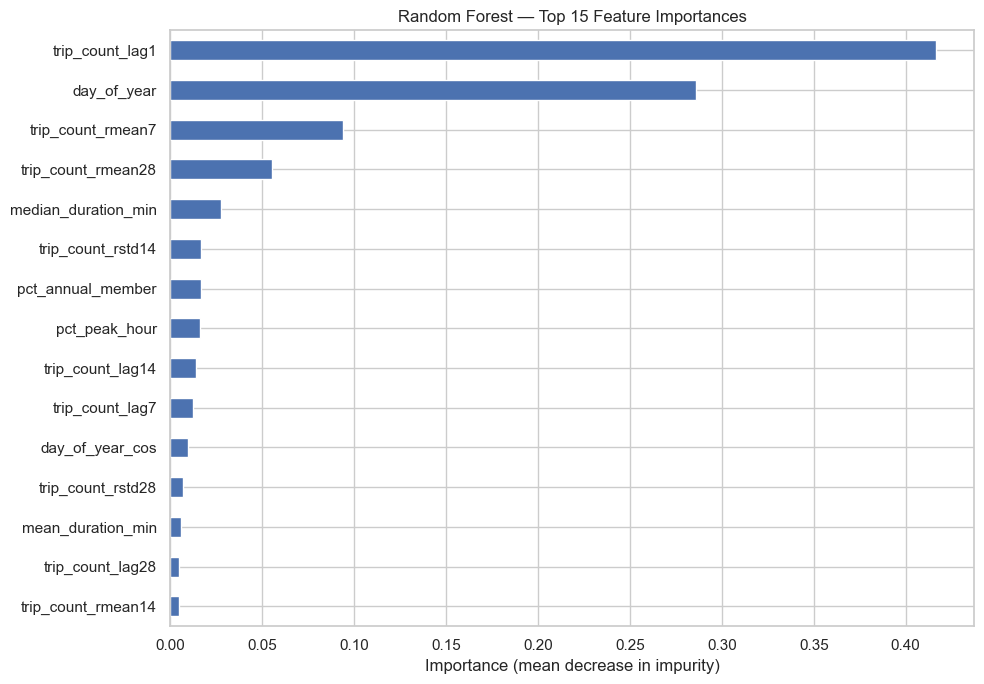

In [13]:
importances = pd.Series(
    rf_tuned.feature_importances_,
    index=feature_cols,
).sort_values(ascending=False)

print("Top 15 features:\n")
print(importances.head(15).round(4))

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(15).plot(kind="barh", ax=ax)
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Model Comparison

How does each approach stack up? We compare all models on the same held-out test set.

                                 RMSE      MAE   MAPE
model                                                
Baseline: Same-Day-Last-Week  3090.76  2484.73  33.38
Baseline: 7-Day Moving Avg    2362.62  1880.09  25.61
Linear Regression             2763.48  2169.73  26.66
Random Forest (baseline)      2916.45  2322.31  37.43
Random Forest (tuned)         3139.17  2530.71  40.66


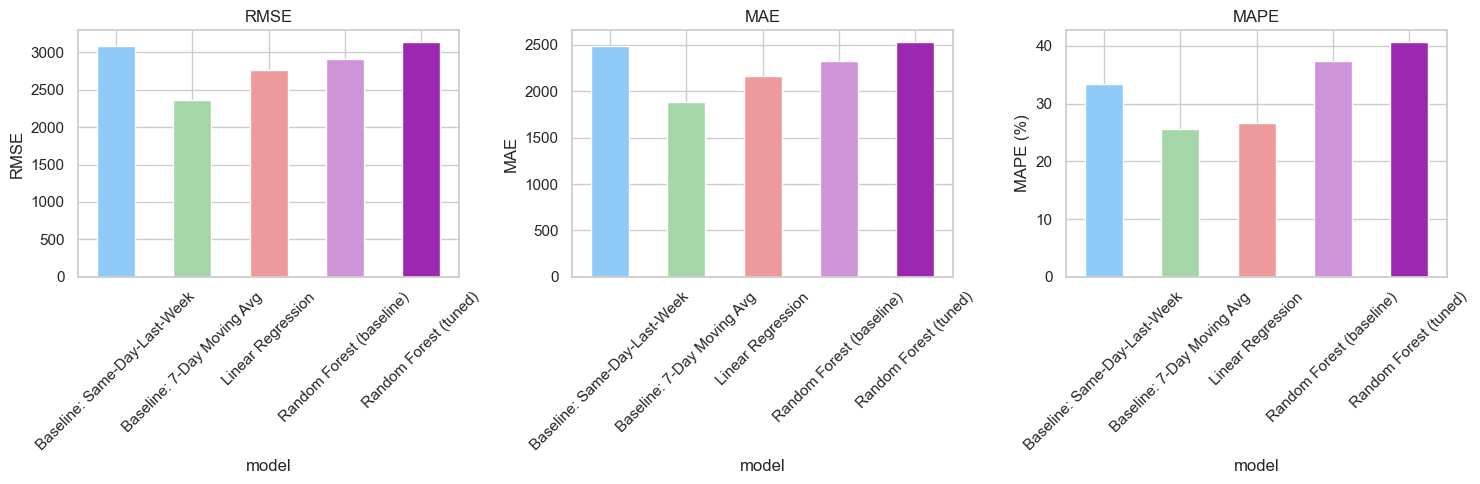

In [14]:
results_df = pd.DataFrame(results).set_index("model")
print(results_df.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#90CAF9", "#A5D6A7", "#EF9A9A", "#CE93D8", "#9C27B0"]

for i, metric in enumerate(["RMSE", "MAE", "MAPE"]):
    results_df[metric].plot(kind="bar", ax=axes[i], color=colors[: len(results_df)])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric + (" (%)" if metric == "MAPE" else ""))
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### All Models: Overlay Plot

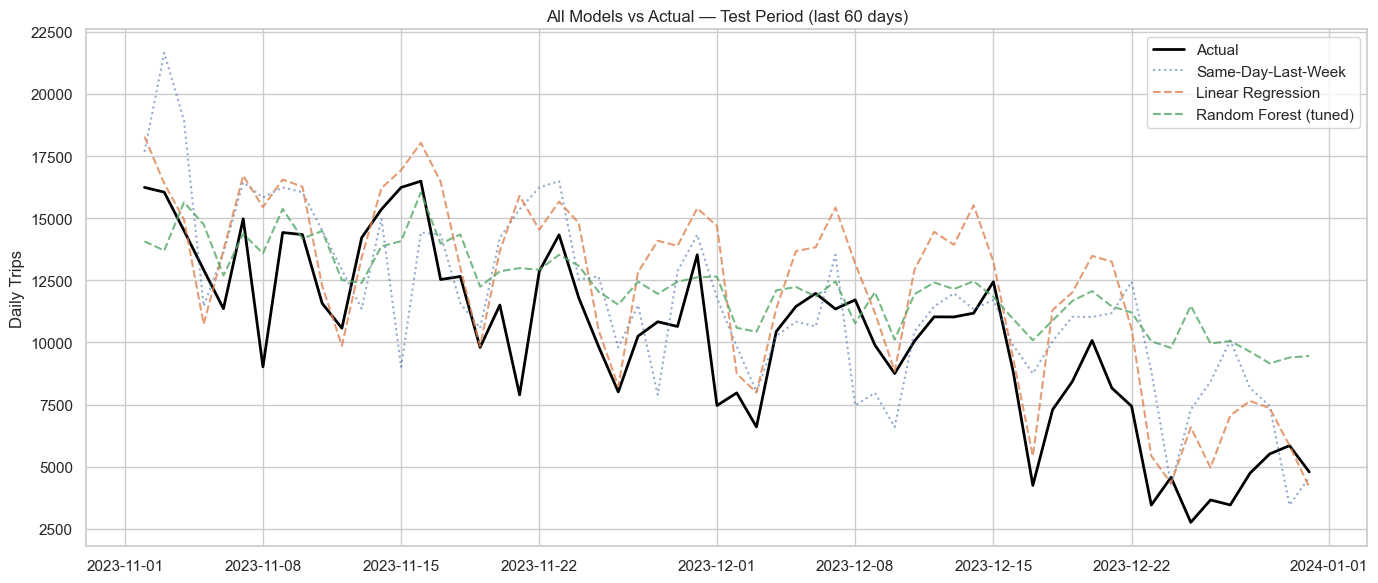

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.index, y_test, label="Actual", color="black", linewidth=2)
ax.plot(y_test.index, baseline_lag7, label="Same-Day-Last-Week", linestyle=":", alpha=0.6)
ax.plot(y_test.index, lr_pred, label="Linear Regression", linestyle="--", alpha=0.8)
ax.plot(y_test.index, rf_tuned_pred, label="Random Forest (tuned)", linestyle="--", alpha=0.8)
ax.set_title("All Models vs Actual — Test Period (last 60 days)")
ax.set_ylabel("Daily Trips")
ax.legend()
plt.tight_layout()
plt.show()

### Residual Analysis

Residuals (actual and predicted) reveal systematic errors. Good residuals should be randomly scattered around zero with no obvious pattern.

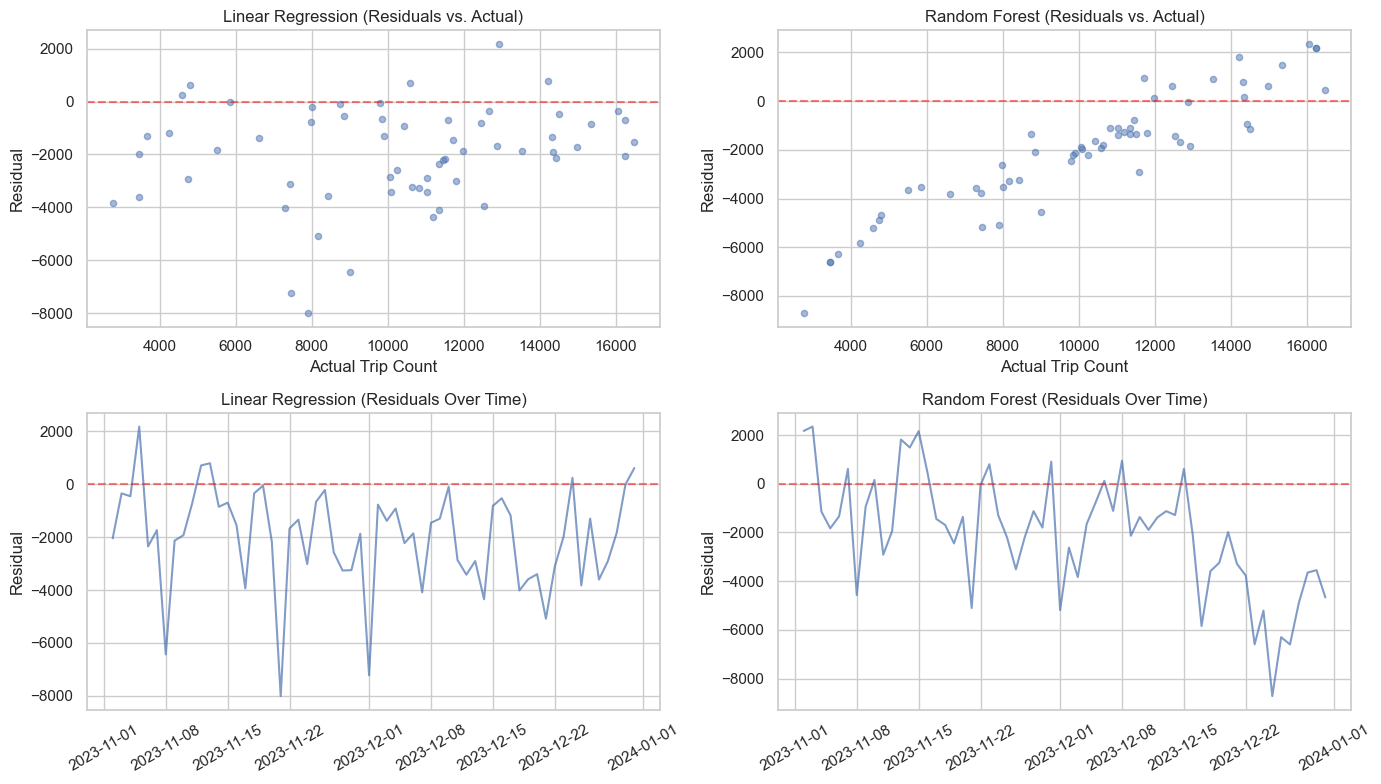

Residual statistics:
       Linear Regression  Random Forest
count               60.0           60.0
mean             -2018.5        -2044.3
std               1903.4         2402.4
min              -8007.5        -8717.1
25%              -3144.4        -3556.7
50%              -1849.9        -1813.7
75%               -706.4         -907.9
max               2178.6         2348.9


In [16]:
residuals = pd.DataFrame(
    {
        "Linear Regression": y_test.values - lr_pred,
        "Random Forest": y_test.values - rf_tuned_pred,
    },
    index=y_test.index,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals vs. actual
for i, col in enumerate(residuals.columns):
    axes[0, i].scatter(y_test.values, residuals[col], alpha=0.5, s=20)
    axes[0, i].axhline(0, color="red", linestyle="--", alpha=0.5)
    axes[0, i].set_title(f"{col} (Residuals vs. Actual)")
    axes[0, i].set_xlabel("Actual Trip Count")
    axes[0, i].set_ylabel("Residual")

# Residuals over time
for i, col in enumerate(residuals.columns):
    axes[1, i].plot(residuals.index, residuals[col], alpha=0.7)
    axes[1, i].axhline(0, color="red", linestyle="--", alpha=0.5)
    axes[1, i].set_title(f"{col} (Residuals Over Time)")
    axes[1, i].set_ylabel("Residual")
    axes[1, i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Residual statistics:")
print(residuals.describe().round(1))

### Conclusions

#### Model Performance Summary

- **Naive baselines** provide a surprisingly strong starting point. The same-day-last-week baseline captures the weekly cycle that dominates this dataset. Any model that can't beat this isn't worth the complexity.

- **Linear Regression** improves on the baselines by combining multiple features (lags, rolling means, cyclical encodings) into a single prediction. Its coefficients are fully interpretable, and we can see exactly how much each feature contributes.

- **Random Forest** typically achieves the best accuracy because it captures non-linear interactions between features (how the effect of a holiday may differ between summer and winter). Hyperparameter tuning with TimeSeriesSplit ensures the model generalizes to future data.

#### Key Takeaways

1. **Lag-7 (same-day-last-week)** is the single most predictive feature, confirming the strong weekly periodicity found in EDA.
1. **Rolling means** (7-day, 28-day) capture the broader seasonal trend and consistently rank as top features.
2. **Cyclical sin/cos encodings** for day-of-week and month allow models to understand that Sunday is close to Monday and December is close to January, without creating 12 separate dummy columns.
3. **Temporal cross-validation** (TimeSeriesSplit) is essential for time series, as random shuffling would leak future information into training.
4. **Always start with baselines.** They ground your evaluation and prevent overstating model performance.

#### Lifecycle Demonstration

This project demonstrates the full AI/ML lifecycle:

- **Data cleanup** (notebook 01): column normalization, IQR outlier removal
- **Exploratory analysis** (notebook 02): seasonality, stationarity, ACF/PACF
- **Feature engineering** (notebook 03): lag/rolling features, cyclical encoding, holiday flags
- **Model development** (this notebook): progressive complexity from baselines o ensemble models
- **Parameter tuning**: GridSearchCV with TimeSeriesSplit for Random Forest
- **Testing & validation**: temporal train/test split, three metrics (RMSE, MAE, MAPE), residual analysis

#### Potential Improvements

- **Weather data:** Temperature and precipitation are likely the strongest missing predictors.
- **Hourly granularity:** Forecasting at the hourly level would be more useful for operational bike redistribution.
- **Station-level models:** Breaking forecasts down by station could help with fleet rebalancing decisions.